# **ResNet-20 on CIFAR-10**
**Based on:** Official Keras ResNet Implementation (Simplified)  
**Syntax Style:** Functional API  

This notebook implements a 20-layer Residual Network (ResNet). By utilizing **Skip Connections (Identity Mappings)**, this architecture solves the Accuracy Degradation problem found in traditional deep networks, achieving high accuracy with only ~270,000 parameters.

In [ ]:
# -*- coding: utf-8 -*-

# ─── ALL IMPORTS AT THE TOP ───────────────────────────────────────────────────
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Conv2D, BatchNormalization, Activation, Add
from tensorflow.keras.layers import AveragePooling2D, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import logging
tf.get_logger().setLevel(logging.ERROR)

EPOCHS = 50
BATCH_SIZE = 64

## **1. Load Dataset & Preprocessing**
Here we load the CIFAR-10 dataset, standardize the pixel values to have a mean of 0 and a standard deviation of 1, and apply real-time data augmentation (horizontal flipping and shifting) to prevent overfitting.

In [ ]:
# ─── 1. Load Dataset & Preprocessing ──────────────────────────────────────────
cifar_dataset = keras.datasets.cifar10
(train_images, train_labels), (test_images, test_labels) = cifar_dataset.load_data()

# Standardize exactly like your previous models
mean   = np.mean(train_images)
stddev = np.std(train_images)
train_images = (train_images - mean) / stddev
test_images  = (test_images  - mean) / stddev

train_labels = to_categorical(train_labels, num_classes=10)
test_labels  = to_categorical(test_labels,  num_classes=10)

datagen = ImageDataGenerator(
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1
)
datagen.fit(train_images)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 445s 3us/step


## **2. Define the ResNet Layer (The Building Block)**
Instead of writing Conv2D, BatchNormalization, and ReLU repeatedly, we define a single helper function. This ensures that **He Normal initialization** and Batch Norm are correctly applied to every convolutional layer in the network.

In [ ]:
# ─── 2. Define the ResNet Layer (From Keras Official) ─────────────────────────
def resnet_layer(inputs, num_filters=16, kernel_size=3, strides=1, activation='relu', batch_normalization=True):
    """2D Convolution-Batch Normalization-Activation stack builder"""
    x = Conv2D(num_filters,
               kernel_size=kernel_size,
               strides=strides,
               padding='same',
               kernel_initializer='he_normal')(inputs)

    if batch_normalization:
        x = BatchNormalization()(x)
    if activation is not None:
        x = Activation(activation)(x)
    return x

## **3. Build ResNet-20 Architecture**
This section dynamically generates the 20-layer architecture using nested loops.
* **The Main Path:** Extracts features using stacked convolutions.
* **The Shortcut (Skip Connection):** Adds the original input back to the output of the convolutions `Add()([x, y])` before applying the final ReLU activation.

In [ ]:
# ─── 3. Build ResNet-20 Architecture ──────────────────────────────────────────
input_layer = Input(shape=(32, 32, 3))

# Initial Convolution (Stem)
x = resnet_layer(inputs=input_layer)

# Instantiate the stack of residual units
num_filters = 16
for stack in range(3):
    # Each stack has 3 blocks (Total 9 blocks = 18 layers + 2 head/stem = ResNet20)
    for res_block in range(3):
        strides = 1
        # Downsample at the beginning of stack 2 and 3
        if stack > 0 and res_block == 0:
            strides = 2

        # Main Path
        y = resnet_layer(inputs=x, num_filters=num_filters, strides=strides)
        y = resnet_layer(inputs=y, num_filters=num_filters, activation=None)

        # Shortcut Connection (Skip)
        if stack > 0 and res_block == 0:
            # Linear projection shortcut to match changed dimensions
            x = resnet_layer(inputs=x, num_filters=num_filters, kernel_size=1,
                             strides=strides, activation=None, batch_normalization=False)

        # Add Shortcut to Main Path and Apply ReLU!
        x = Add()([x, y])
        x = Activation('relu')(x)

    num_filters *= 2 # Double filters after each stack (16 -> 32 -> 64)

# --- HEAD ---
x = AveragePooling2D(pool_size=8)(x)
y = Flatten()(x)
output_layer = Dense(10, activation='softmax', kernel_initializer='he_normal')(y)

# Create Model
model = Model(inputs=input_layer, outputs=output_layer)

# Compile using standard Adam
model.compile(loss='categorical_crossentropy',
              optimizer=Adam(learning_rate=0.001),
              metrics=['accuracy'])

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 32, 32,    │        448 │ input_layer[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 32, 32,    │         64 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 32, 32,    │      2,320 │ activation[0][0]  │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │         64 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 32, 32,    │      2,320 │ activation_1[0][… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │         64 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 32, 32,    │          0 │ activation[0][0], │
│                     │ 16)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 32, 32,    │          0 │ add[0][0]         │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 32, 32,    │      2,320 │ activation_2[0][… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │         64 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │      2,320 │ activation_3[0][… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │         64 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 32, 32,    │          0 │ activation_2[0][

 Total params: 274,442 (1.05 MB)

 Trainable params: 273,066 (1.04 MB)

 Non-trainable params: 1,376 (5.38 KB)

## **4. Train the Network**
We train the model using our augmented data generator. The history object will capture the loss and accuracy metrics for our evaluation graphs.

In [ ]:
# ─── 4. Train ─────────────────────────────────────────────────────────────────
print("\nTraining ResNet-20 (Clean Version)...")
history = model.fit(
    datagen.flow(train_images, train_labels, batch_size=BATCH_SIZE),
    validation_data=(test_images, test_labels),
    epochs=EPOCHS,
    verbose=2
)


Training ResNet-20 (Clean Version)...
Epoch 1/50
782/782 - 66s - 85ms/step - accuracy: 0.4725 - loss: 1.4449 - val_accuracy: 0.5099 - val_loss: 1.4005
Epoch 2/50
782/782 - 34s - 43ms/step - accuracy: 0.6164 - loss: 1.0739 - val_accuracy: 0.6180 - val_loss: 1.0950
Epoch 3/50
782/782 - 35s - 45ms/step - accuracy: 0.6839 - loss: 0.8979 - val_accuracy: 0.5986 - val_loss: 1.3078
Epoch 4/50
782/782 - 36s - 46ms/step - accuracy: 0.7276 - loss: 0.7819 - val_accuracy: 0.7312 - val_loss: 0.7782
Epoch 5/50
782/782 - 35s - 45ms/step - accuracy: 0.7528 - loss: 0.7146 - val_accuracy: 0.6816 - val_loss: 0.9498
Epoch 6/50
782/782 - 34s - 44ms/step - accuracy: 0.7726 - loss: 0.6564 - val_accuracy: 0.7582 - val_loss: 0.7047
Epoch 7/50
782/782 - 43s - 55ms/step - accuracy: 0.7866 - loss: 0.6089 - val_accuracy: 0.7162 - val_loss: 0.8896
Epoch 8/50
782/782 - 36s - 46ms/step - accuracy: 0.8010 - loss: 0.5753 - val_accuracy: 0.7717 - val_loss: 0.6603
Epoch 9/50
782/782 - 36s - 45ms/step - accuracy: 0.8137 -

## **5. Performance Evaluation**
Visualizing the training vs. validation curves for Error, Loss, and Accuracy to monitor convergence and ensure the model is not overfitting.

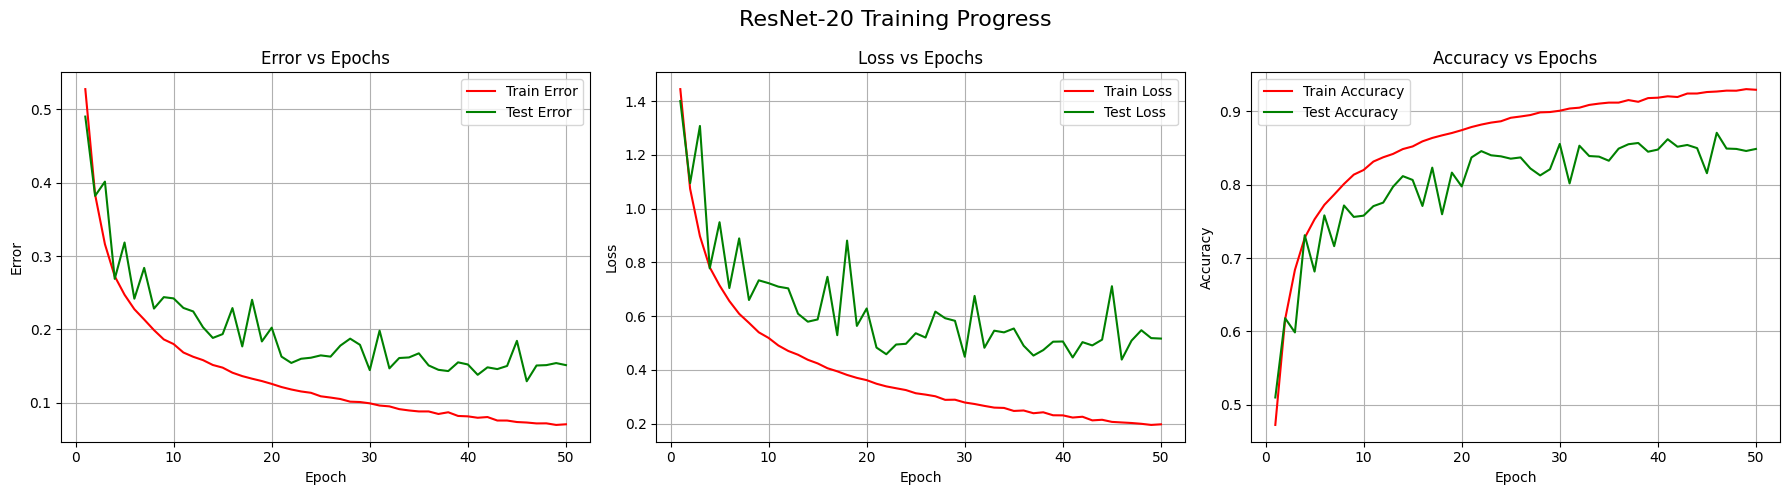

In [ ]:
# ─── 5. Plot: Error, Loss, and Accuracy ───────────────────────────────────────
train_error =[1 - acc for acc in history.history['accuracy']]
test_error  =[1 - acc for acc in history.history['val_accuracy']]
epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(18, 5))

# Plot 1: Error
plt.subplot(1, 3, 1)
plt.plot(epochs_range, train_error, color='red',   label='Train Error')
plt.plot(epochs_range, test_error,  color='green', label='Test Error')
plt.xlabel('Epoch')
plt.ylabel('Error')
plt.title('Error vs Epochs')
plt.legend()
plt.grid(True)

# Plot 2: Loss
plt.subplot(1, 3, 2)
plt.plot(epochs_range, history.history['loss'],     label='Train Loss',  color='red')
plt.plot(epochs_range, history.history['val_loss'], label='Test Loss',   color='green')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss vs Epochs')
plt.legend()
plt.grid(True)

# Plot 3: Accuracy
plt.subplot(1, 3, 3)
plt.plot(epochs_range, history.history['accuracy'],     label='Train Accuracy', color='red')
plt.plot(epochs_range, history.history['val_accuracy'], label='Test Accuracy',  color='green')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Epochs')
plt.legend()
plt.grid(True)

plt.suptitle('ResNet-20 Training Progress', fontsize=16)
plt.tight_layout()
plt.show()